In [1]:
import qsharp
import random
import json
import time
from diskcache import Cache
from matplotlib import pyplot as plt

cache = Cache("~/quant-arith-cache/re-multipliers")
qsharp.init(project_root="../")

@cache.memoize()
def estimate_resources_multiply(op, n):
    est = qsharp.estimate(f"EstimateUtils.RunMultiply({n},{op})")
    return json.dumps(est)    

2 QuantumArithmetic.CG2019.MultiplySchoolbook 0.0005862712860107422
3 QuantumArithmetic.CG2019.MultiplySchoolbook 0.00036525726318359375
4 QuantumArithmetic.CG2019.MultiplySchoolbook 0.00024080276489257812
5 QuantumArithmetic.CG2019.MultiplySchoolbook 0.0001571178436279297
6 QuantumArithmetic.CG2019.MultiplySchoolbook 0.00015401840209960938
7 QuantumArithmetic.CG2019.MultiplySchoolbook 0.0003752708435058594
8 QuantumArithmetic.CG2019.MultiplySchoolbook 0.0002465248107910156
10 QuantumArithmetic.CG2019.MultiplySchoolbook 0.0001609325408935547
11 QuantumArithmetic.CG2019.MultiplySchoolbook 0.00029969215393066406
13 QuantumArithmetic.CG2019.MultiplySchoolbook 0.00016999244689941406
16 QuantumArithmetic.CG2019.MultiplySchoolbook 0.000270843505859375
19 QuantumArithmetic.CG2019.MultiplySchoolbook 0.00015020370483398438
23 QuantumArithmetic.CG2019.MultiplySchoolbook 0.0003063678741455078
27 QuantumArithmetic.CG2019.MultiplySchoolbook 0.0002231597900390625
32 QuantumArithmetic.CG2019.Multiply

7 QuantumArithmetic.CG2019.MultiplyKaratsuba32 0.00013375282287597656
8 QuantumArithmetic.CG2019.MultiplyKaratsuba32 0.00023221969604492188
10 QuantumArithmetic.CG2019.MultiplyKaratsuba32 0.0003044605255126953
11 QuantumArithmetic.CG2019.MultiplyKaratsuba32 0.00021958351135253906
13 QuantumArithmetic.CG2019.MultiplyKaratsuba32 0.00024890899658203125
16 QuantumArithmetic.CG2019.MultiplyKaratsuba32 0.0002532005310058594
19 QuantumArithmetic.CG2019.MultiplyKaratsuba32 0.00024056434631347656
23 QuantumArithmetic.CG2019.MultiplyKaratsuba32 0.00021719932556152344
27 QuantumArithmetic.CG2019.MultiplyKaratsuba32 0.00020956993103027344
32 QuantumArithmetic.CG2019.MultiplyKaratsuba32 0.0002079010009765625
38 QuantumArithmetic.CG2019.MultiplyKaratsuba32 0.0001385211944580078
45 QuantumArithmetic.CG2019.MultiplyKaratsuba32 0.0001392364501953125
54 QuantumArithmetic.CG2019.MultiplyKaratsuba32 0.000133514404296875
64 QuantumArithmetic.CG2019.MultiplyKaratsuba32 0.00014543533325195312
76 QuantumArith

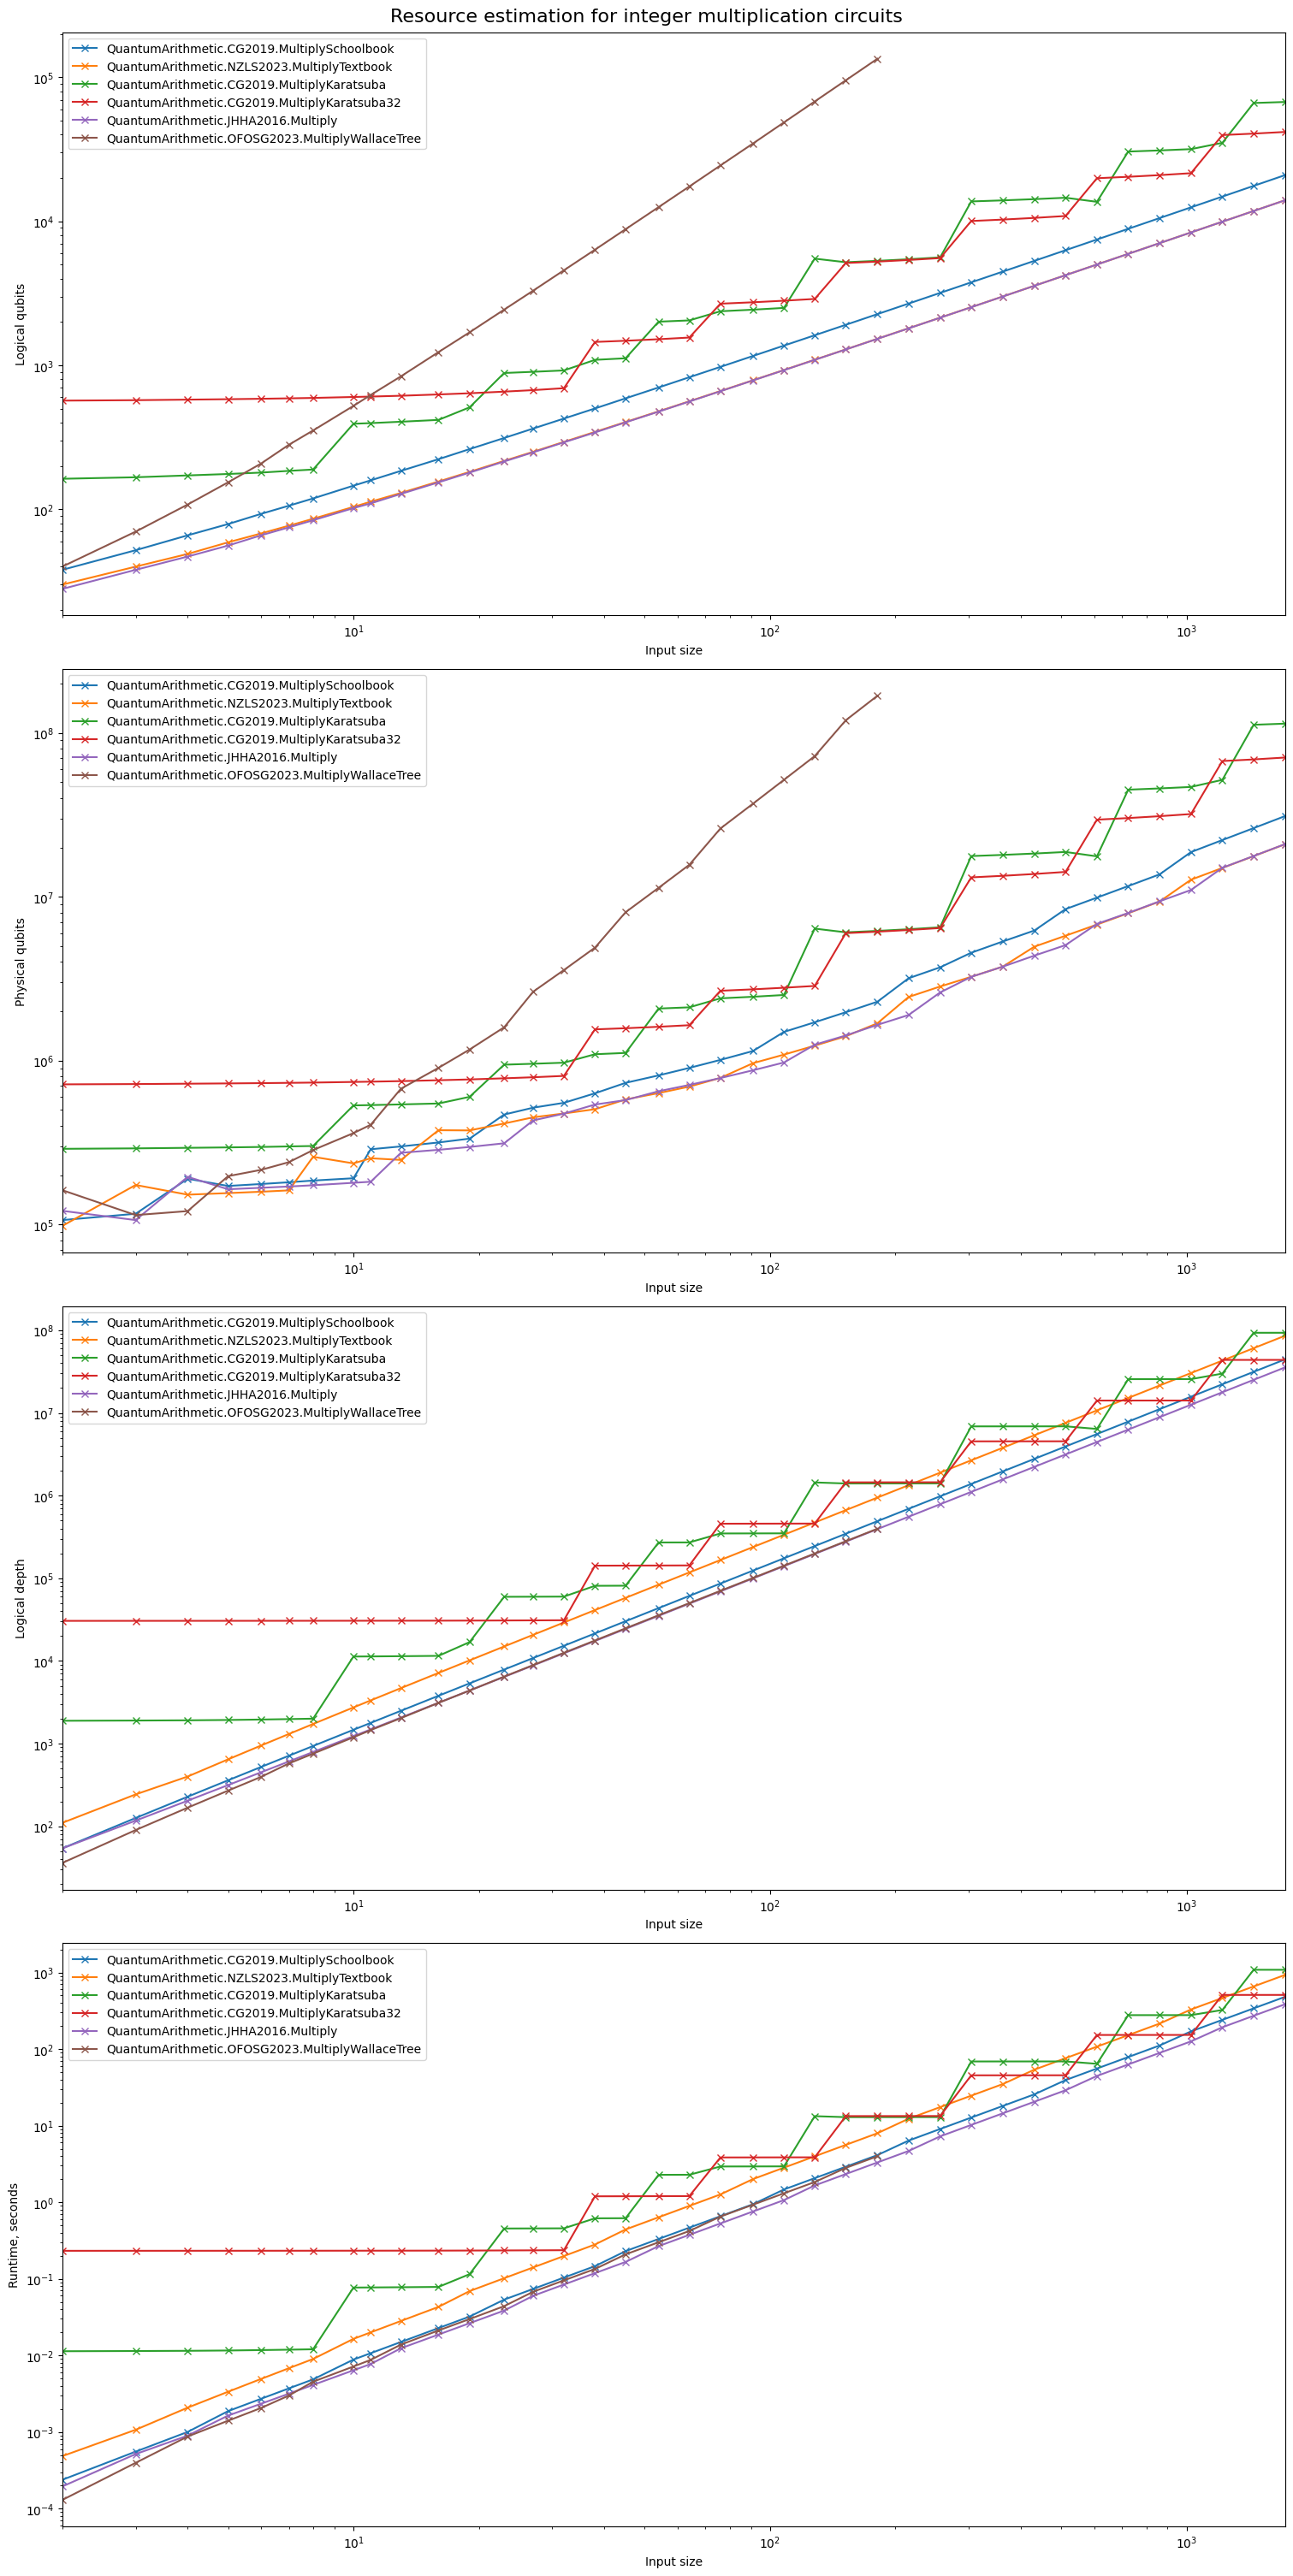

In [2]:
ops = [
  "QuantumArithmetic.CG2019.MultiplySchoolbook",
  "QuantumArithmetic.NZLS2023.MultiplyTextbook",
  "QuantumArithmetic.CG2019.MultiplyKaratsuba",
  "QuantumArithmetic.CG2019.MultiplyKaratsuba32",  
  "QuantumArithmetic.JHHA2016.Multiply",  
  "QuantumArithmetic.OFOSG2023.MultiplyWallaceTree",  
]

small_n_range = [2,3] + [int(round(2**(0.25*i))) for i in range(8,31)]
default_n_range = [2,3] + [int(round(2**(0.25*i))) for i in range(8,60)]
n_ranges = {op: default_n_range for op in ops}
n_ranges["QuantumArithmetic.OFOSG2023.MultiplyWallaceTree"] = small_n_range

metrics = ["Logical qubits", "Physical qubits", "Logical depth", "Runtime, seconds"]
charts = [{op: [] for op in ops} for _ in range(len(metrics))]

for op in ops:
    for n in n_ranges[op]:
        t0=time.time()
        estimates = json.loads(estimate_resources_multiply(op, n))
        print(n, op, time.time()-t0, flush=True)
        charts[0][op].append(estimates['physicalCounts']['breakdown']['algorithmicLogicalQubits'])
        charts[1][op].append(estimates['physicalCounts']['physicalQubits'])
        charts[2][op].append(estimates['physicalCounts']['breakdown']['logicalDepth'])
        charts[3][op].append(estimates['physicalCounts']['runtime']/10**9)
        
    
fig, ax = plt.subplots(figsize=(15, 30), nrows=len(metrics), ncols=1, constrained_layout=True)
for i in range(len(metrics)):
    for op in ops:
        ax[i].plot(n_ranges[op], charts[i][op], label=op, marker='x')
    ax[i].set_xlim([2,max(max(n_ranges[op]) for op in ops)])
    ax[i].legend()
    ax[i].set_xlabel('Input size')
    ax[i].set_ylabel(metrics[i])
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
fig.suptitle("Resource estimation for integer multiplication circuits", fontsize=16)
plt.show()